In [2]:
import pandas as pd

def LabelEncoding(df, column):
    unique_values = df[column].unique()

    label_dict = {}
    for i, value in enumerate(unique_values):
        label_dict[value] = i

    encoded_df = pd.DataFrame()
    encoded_df[column + "_Label"] = df[column].map(label_dict)

    return encoded_df


def OneHotEncoding(df, column):
    unique_values = df[column].unique()

    encoded_df = pd.DataFrame(index=df.index)

    for value in unique_values:
        encoded_df[str(value)] = (df[column] == value).astype(int)

    return encoded_df


df = pd.read_excel(
    r"C:\Users\ivysa\Downloads\Lab Session Data.xlsx",
    sheet_name="marketing_campaign"
)



label_encoded = LabelEncoding(df, "Education")
one_hot_encoded = OneHotEncoding(df, "Marital_Status")

print(label_encoded)
print(one_hot_encoded)

      Education_Label
0                   0
1                   0
2                   0
3                   0
4                   1
...               ...
2235                0
2236                1
2237                0
2238                2
2239                1

[2240 rows x 1 columns]
      Single  Together  Married  Divorced  Widow  Alone  Absurd  YOLO
0          1         0        0         0      0      0       0     0
1          1         0        0         0      0      0       0     0
2          0         1        0         0      0      0       0     0
3          0         1        0         0      0      0       0     0
4          0         0        1         0      0      0       0     0
...      ...       ...      ...       ...    ...    ...     ...   ...
2235       0         0        1         0      0      0       0     0
2236       0         1        0         0      0      0       0     0
2237       0         0        0         1      0      0       0     0
2238       

In [3]:
def MinkowskiDist(X, Y, p):
    if len(X) != len(Y):
        raise ValueError("Both points must have the same number of dimensions.")

    distance = 0

    for i in range(len(X)):
        distance += abs(X[i] - Y[i]) ** p

    distance = distance ** (1 / p)

    if p == 1:
        print("It is Manhattan Distance.")
    elif p == 2:
        print("It is Euclidean Distance.")

    return distance

X = [2, 3, 4]
Y = [5, 7, 1]

print("Distance =", MinkowskiDist(X, Y, 1))
print("Distance =", MinkowskiDist(X, Y, 2))
print("Distance =", MinkowskiDist(X, Y, 3))

It is Manhattan Distance.
Distance = 10.0
It is Euclidean Distance.
Distance = 5.830951894845301
Distance = 4.904868131524016


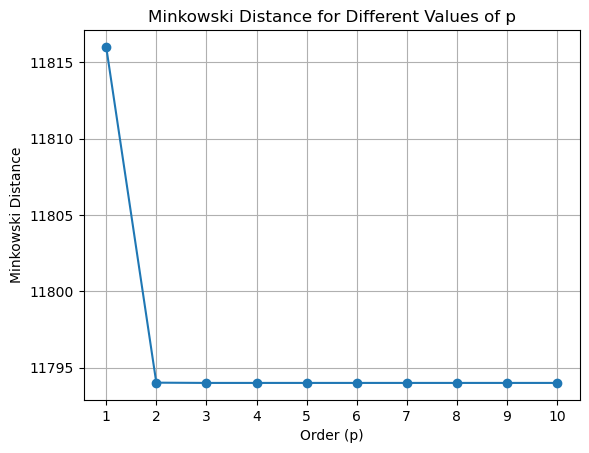

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

def MinkowskiDist(X, Y, p):
    if len(X) != len(Y):
        raise ValueError("Both feature vectors must have the same dimensions.")

    distance = 0

    for i in range(len(X)):
        distance += abs(X[i] - Y[i]) ** p

    distance = distance ** (1 / p)

    return distance


df = pd.read_excel(
    r"C:\Users\ivysa\Downloads\Lab Session Data.xlsx",
    sheet_name="marketing_campaign"
)

# Select only numerical feature columns
features = ["Income", "Kidhome", "Teenhome", "Recency"]

X = df.loc[0, features].values
Y = df.loc[1, features].values

p_values = []
distances = []

for p in range(1, 11):
    distance = MinkowskiDist(X, Y, p)
    p_values.append(p)
    distances.append(distance)

plt.plot(p_values, distances, marker='o')
plt.title("Minkowski Distance for Different Values of p")
plt.xlabel("Order (p)")
plt.ylabel("Minkowski Distance")
plt.xticks(range(1, 11))
plt.grid(True)
plt.show()

In [6]:
import pandas as pd
from scipy.spatial.distance import minkowski

def MinkowskiDist(X, Y, p):
    if len(X) != len(Y):
        raise ValueError("Both feature vectors must have the same dimensions.")

    distance = 0

    for i in range(len(X)):
        distance += abs(X[i] - Y[i]) ** p

    distance = distance ** (1 / p)

    if p == 1:
        print("It is Manhattan Distance.")
    elif p == 2:
        print("It is Euclidean Distance.")

    return distance


df = pd.read_excel(
    r"C:\Users\ivysa\Downloads\Lab Session Data.xlsx",
    sheet_name="marketing_campaign"
)

numeric_df = df.select_dtypes(include="number")


X = numeric_df.iloc[0].values
Y = numeric_df.iloc[1].values

p = 3

my_distance = MinkowskiDist(X, Y, p)
scipy_distance = minkowski(X, Y, p)

print("Distance using user-defined function :", my_distance)
print("Distance using scipy function        :", scipy_distance)

c:\users\ivysa\anaconda3\lib\site-packages\scipy\__init__.py:138: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.24.4)
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion} is required for this version of "


Distance using user-defined function : 11884.37455405266
Distance using scipy function        : 11884.37455405266


In [7]:
import numpy as np

def DotProduct(A, B):
    if len(A) != len(B):
        raise ValueError("Vectors must have the same length.")

    dot = 0
    for i in range(len(A)):
        dot += A[i] * B[i]

    return dot


def EuclideanNorm(A):
    norm = 0
    for i in range(len(A)):
        norm += A[i] ** 2

    return norm ** 0.5


A = np.array([2, 4, 6, 8])
B = np.array([1, 3, 5, 7])

manual_dot = DotProduct(A, B)
manual_norm_A = EuclideanNorm(A)
manual_norm_B = EuclideanNorm(B)

numpy_dot = np.dot(A, B)
numpy_norm_A = np.linalg.norm(A)
numpy_norm_B = np.linalg.norm(B)

print("Manual Dot Product :", manual_dot)
print("NumPy Dot Product  :", numpy_dot)

print("\nManual Euclidean Norm of A :", manual_norm_A)
print("NumPy Euclidean Norm of A  :", numpy_norm_A)

print("\nManual Euclidean Norm of B :", manual_norm_B)
print("NumPy Euclidean Norm of B  :", numpy_norm_B)

Manual Dot Product : 100
NumPy Dot Product  : 100

Manual Euclidean Norm of A : 10.954451150103322
NumPy Euclidean Norm of A  : 10.954451150103322

Manual Euclidean Norm of B : 9.16515138991168
NumPy Euclidean Norm of B  : 9.16515138991168


In [8]:
import pandas as pd

def Mean(data):
    total = 0

    for value in data:
        total += value

    return total / len(data)

def Variance(data):
    mean = Mean(data)

    variance = 0

    for value in data:
        variance += (value - mean) ** 2

    return variance / len(data)      # Population Variance


def StandardDeviation(data):
    variance = Variance(data)

    return variance ** 0.5


# for every feature (column) in the dataset
def FeatureStatistics(df):
    statistics = pd.DataFrame(
        columns=["Feature", "Mean", "Variance", "Standard Deviation"]
    )

    for column in df.columns:
        statistics.loc[len(statistics)] = [
            column,
            Mean(df[column]),
            Variance(df[column]),
            StandardDeviation(df[column])
        ]

    return statistics

df = pd.read_excel(
    r"C:\Users\ivysa\Downloads\Lab Session Data.xlsx",
    sheet_name="marketing_campaign"
)

numeric_df = df.select_dtypes(include="number")
result = FeatureStatistics(numeric_df)
print(result)

                Feature         Mean      Variance  Standard Deviation
0                    ID  5592.159821  1.053611e+07         3245.937415
1            Year_Birth  1968.805804  1.435538e+02           11.981394
2                Income          NaN           NaN                 NaN
3               Kidhome     0.444196  2.897431e-01            0.538278
4              Teenhome     0.506250  2.963895e-01            0.544417
5               Recency    49.109375  8.384492e+02           28.955987
6              MntWines   303.935714  1.132472e+05          336.522251
7             MntFruits    26.302232  1.581220e+03           39.764555
8       MntMeatProducts   166.950000  5.092469e+04          225.664984
9       MntFishProducts    37.525446  2.982993e+03           54.616784
10     MntSweetProducts    27.062946  1.703319e+03           41.271283
11         MntGoldProds    44.021875  2.720227e+03           52.155793
12    NumDealsPurchases     2.325000  3.731875e+00            1.931806
13    

In [10]:
import pandas as pd
import numpy as np

def Mean(data):
    total = 0

    for value in data:
        total += value

    return total / len(data)


def Variance(data):
    mean = Mean(data)

    variance = 0

    for value in data:
        variance += (value - mean) ** 2

    return variance / len(data)

def StandardDeviation(data):
    return Variance(data) ** 0.5


def ManualStatistics(df):
    means = []
    stds = []

    for column in df.columns:
        means.append(Mean(df[column]))
        stds.append(StandardDeviation(df[column]))

    return means, stds


df = pd.read_excel(
    r"C:\Users\ivysa\Downloads\Lab Session Data.xlsx",
    sheet_name="marketing_campaign"
)

numeric_df = df.select_dtypes(include="number")

manual_mean, manual_std = ManualStatistics(numeric_df)

# NumPy calculations (column-wise)
numpy_mean = np.mean(numeric_df, axis=0)
numpy_std = np.std(numeric_df, axis=0)

comparison = pd.DataFrame({
    #"Feature": numeric_df.columns,
    "Manual Mean": manual_mean,
    "NumPy Mean": numpy_mean,
    "Manual Std Dev": manual_std,
    "NumPy Std Dev": numpy_std
})

print(comparison)

                     Manual Mean    NumPy Mean  Manual Std Dev  NumPy Std Dev
ID                   5592.159821   5592.159821     3245.937415    3245.937415
Year_Birth           1968.805804   1968.805804       11.981394      11.981394
Income                       NaN  52247.251354             NaN   25167.396174
Kidhome                 0.444196      0.444196        0.538278       0.538278
Teenhome                0.506250      0.506250        0.544417       0.544417
Recency                49.109375     49.109375       28.955987      28.955987
MntWines              303.935714    303.935714      336.522251     336.522251
MntFruits              26.302232     26.302232       39.764555      39.764555
MntMeatProducts       166.950000    166.950000      225.664984     225.664984
MntFishProducts        37.525446     37.525446       54.616784      54.616784
MntSweetProducts       27.062946     27.062946       41.271283      41.271283
MntGoldProds           44.021875     44.021875       52.155793  